# 사이킷런(Scikit-learn) 

**학습 목표:** 사이킷런을 이용한 머신러닝 전체 파이프라인 이해
- 데이터 로드 → 전처리 → 모델 학습 → 평가까지 흐름을 익힌다.
- 교차 검증, 하이퍼파라미터 튜닝 방법을 이해한다.

---

## 1. 첫 번째 머신러닝 — 붓꽃(Iris) 품종 예측

**머신러닝 기본 흐름:**
```
데이터 로드 → train/test 분리 → 모델 학습(fit) → 예측(predict) → 평가(accuracy)
```

붓꽃 데이터셋은 꽃받침/꽃잎의 길이·너비 4개 feature로 3종(Setosa, Versicolor, Virginica)을 분류하는 대표적인 입문용 데이터셋이다.

In [1]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

In [2]:
# 붓꽃 데이터 로드
# load_iris()는 sklearn 내장 데이터셋 → Bunch 객체(dict-like) 반환
iris = load_iris()

iris_data  = iris.data    # feature 행렬 (numpy array, shape: 150×4)
iris_label = iris.target  # label 벡터 (0=setosa, 1=versicolor, 2=virginica)

print('target값:', iris_label)
print('target명:', iris.target_names)

target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
target명: ['setosa' 'versicolor' 'virginica']


In [3]:
# 데이터 확인용 DataFrame 변환 (분석 편의)
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['label'] = iris.target
iris_df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [4]:
# train/test 분리
# test_size=0.2 → 전체의 20%를 테스트용으로 사용
# random_state → 재현성 확보 (같은 숫자면 항상 동일하게 분리)
X_train, X_test, y_train, y_test = train_test_split(
    iris_data, iris_label,
    test_size=0.2, random_state=11
)

In [5]:
# 결정 트리 분류기 생성 및 학습
# fit(X, y) : 학습 데이터로 모델 파라미터 결정
dt_clf = DecisionTreeClassifier(random_state=11)
dt_clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,11
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
# 예측 및 정확도 평가
# predict(X_test) → 학습된 모델로 테스트 데이터 예측
pred = dt_clf.predict(X_test)
print('예측 정확도: {:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9333


---
## 2. 사이킷런 기반 프레임워크 — Bunch 객체 구조 파악

사이킷런 내장 데이터셋은 `Bunch` 객체로 반환된다.  
주요 키: `data`, `target`, `feature_names`, `target_names`, `DESCR`

In [7]:
iris_data = load_iris()

# Bunch 객체의 키 목록 확인
print(type(iris_data))
print('키 목록:', iris_data.keys())

<class 'sklearn.utils._bunch.Bunch'>
키 목록: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [8]:
# 각 속성의 type과 shape 확인 → 데이터 구조 파악 습관
print('feature_names type:', type(iris_data.feature_names))
print('feature_names:', iris_data.feature_names)

print('\ntarget_names type:', type(iris_data.target_names))
print('target_names:', iris_data.target_names)

print('\ndata type:', type(iris_data.data))
print('data shape:', iris_data.data.shape)   # (샘플 수, feature 수)

print('\ntarget type:', type(iris_data.target))
print('target shape:', iris_data.target.shape)

feature_names type: <class 'list'>
feature_names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

target_names type: <class 'numpy.ndarray'>
target_names: ['setosa' 'versicolor' 'virginica']

data type: <class 'numpy.ndarray'>
data shape: (150, 4)

target type: <class 'numpy.ndarray'>
target shape: (150,)


---
## 3. Model Selection — 학습/테스트 분리 & 교차 검증 & GridSearchCV

### 3-1. train_test_split의 한계

학습 데이터로 학습하고, 같은 학습 데이터로 평가하면 **과적합(overfitting)** 발생 → 정확도가 뻥튀기됨.

In [9]:
# 잘못된 예시: 학습 데이터로 예측 → 100% 정확도 (실제로는 의미 없음)
iris = load_iris()
dt_clf = DecisionTreeClassifier()
dt_clf.fit(iris.data, iris.target)

pred = dt_clf.predict(iris.data)  # ← 학습 데이터를 그대로 테스트에 사용 (잘못된 방법)
print('예측 정확도(잘못된 방법):', accuracy_score(iris.target, pred))  # 1.0 나옴

예측 정확도(잘못된 방법): 1.0


### 3-2. K-Fold 교차 검증

데이터를 K개로 나눠 번갈아가며 검증 세트로 사용 → 더 신뢰할 수 있는 성능 추정

```
Fold 1: [검증] [학습] [학습] [학습] [학습]
Fold 2: [학습] [검증] [학습] [학습] [학습]
...
```

In [10]:
from sklearn.model_selection import KFold

iris   = load_iris()
features = iris.data
label    = iris.target
dt_clf   = DecisionTreeClassifier(random_state=156)

# 5-Fold 객체 생성
kfold = KFold(n_splits=5)
cv_accuracy = []
n_iter = 0

# kfold.split(X) → 각 fold의 학습/검증 인덱스를 yield
for train_index, test_index in kfold.split(features):
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index],    label[test_index]

    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    n_iter += 1

    accuracy = np.round(accuracy_score(y_test, pred), 4)
    print('#{} 정확도: {}, 학습크기: {}, 검증크기: {}'.format(
        n_iter, accuracy, X_train.shape[0], X_test.shape[0]))
    cv_accuracy.append(accuracy)

print('\n평균 검증 정확도:', np.mean(cv_accuracy))

#1 정확도: 1.0, 학습크기: 120, 검증크기: 30
#2 정확도: 0.9667, 학습크기: 120, 검증크기: 30
#3 정확도: 0.8667, 학습크기: 120, 검증크기: 30
#4 정확도: 0.9333, 학습크기: 120, 검증크기: 30
#5 정확도: 0.7333, 학습크기: 120, 검증크기: 30

평균 검증 정확도: 0.9


### 3-3. Stratified K-Fold

일반 K-Fold는 클래스 비율을 고려하지 않아 특정 fold에 한 클래스만 몰릴 수 있음.  
**StratifiedKFold**는 각 fold 내에서 클래스 비율을 원본과 동일하게 유지.

In [11]:
# 일반 KFold의 문제 확인: n_splits=3일 때 레이블 분포 불균형
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['label'] = iris.target

kfold = KFold(n_splits=3)
n_iter = 0
for train_index, test_index in kfold.split(iris_df):
    n_iter += 1
    label_train = iris_df['label'].iloc[train_index]
    label_test  = iris_df['label'].iloc[test_index]
    print('## 교차검증 {}  학습분포:\n{}'.format(n_iter, label_train.value_counts()))
    print('검증분포:\n{}\n'.format(label_test.value_counts()))

## 교차검증 1  학습분포:
label
1    50
2    50
Name: count, dtype: int64
검증분포:
label
0    50
Name: count, dtype: int64

## 교차검증 2  학습분포:
label
0    50
2    50
Name: count, dtype: int64
검증분포:
label
1    50
Name: count, dtype: int64

## 교차검증 3  학습분포:
label
0    50
1    50
Name: count, dtype: int64
검증분포:
label
2    50
Name: count, dtype: int64



In [12]:
from sklearn.model_selection import StratifiedKFold

# StratifiedKFold: split(X, y)에 레이블도 함께 전달해야 함
skf    = StratifiedKFold(n_splits=3)
n_iter = 0

for train_index, test_index in skf.split(iris_df, iris_df['label']):
    n_iter += 1
    label_train = iris_df['label'].iloc[train_index]
    label_test  = iris_df['label'].iloc[test_index]
    print('## 교차검증 {}  학습분포:\n{}'.format(n_iter, label_train.value_counts()))
    print('검증분포:\n{}\n'.format(label_test.value_counts()))

## 교차검증 1  학습분포:
label
2    34
0    33
1    33
Name: count, dtype: int64
검증분포:
label
0    17
1    17
2    16
Name: count, dtype: int64

## 교차검증 2  학습분포:
label
1    34
0    33
2    33
Name: count, dtype: int64
검증분포:
label
0    17
2    17
1    16
Name: count, dtype: int64

## 교차검증 3  학습분포:
label
0    34
1    33
2    33
Name: count, dtype: int64
검증분포:
label
1    17
2    17
0    16
Name: count, dtype: int64



In [13]:
# StratifiedKFold로 실제 정확도 측정
dt_clf  = DecisionTreeClassifier(random_state=156)
skfold  = StratifiedKFold(n_splits=3)
n_iter  = 0
cv_accuracy = []

for train_index, test_index in skfold.split(features, label):
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index],    label[test_index]

    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    n_iter += 1

    accuracy = np.round(accuracy_score(y_test, pred), 4)
    print('#{} 정확도: {}'.format(n_iter, accuracy))
    cv_accuracy.append(accuracy)

print('\n교차검증별 정확도:', np.round(cv_accuracy, 4))
print('평균 정확도:', np.round(np.mean(cv_accuracy), 4))

#1 정확도: 0.98
#2 정확도: 0.94
#3 정확도: 0.98

교차검증별 정확도: [0.98 0.94 0.98]
평균 정확도: 0.9667


### 3-4. cross_val_score() — K-Fold 루프를 한 줄로

위의 StratifiedKFold 루프를 내부적으로 처리해주는 편의 함수.  
분류 문제에서는 자동으로 StratifiedKFold를 사용한다.

In [14]:
from sklearn.model_selection import cross_val_score

iris_data = load_iris()
dt_clf    = DecisionTreeClassifier(random_state=156)

# scoring='accuracy', cv=3 → 3-fold 교차검증
scores = cross_val_score(dt_clf, iris_data.data, iris_data.target,
                         scoring='accuracy', cv=3)

print('교차검증별 정확도:', np.round(scores, 4))
print('평균 정확도:', np.round(np.mean(scores), 4))

교차검증별 정확도: [0.98 0.94 0.98]
평균 정확도: 0.9667


### 3-5. GridSearchCV — 하이퍼파라미터 자동 탐색

지정한 파라미터 조합을 교차검증으로 전부 실험 → 최적 조합 자동 선택  
`refit=True` (기본값): 최적 파라미터로 전체 학습 데이터에 재학습

In [15]:
from sklearn.model_selection import GridSearchCV

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=121)

dtree = DecisionTreeClassifier()

# 탐색할 하이퍼파라미터 딕셔너리
# max_depth: 트리 최대 깊이, min_samples_split: 분기 최소 샘플 수
parameters = {'max_depth': [1, 2, 3], 'min_samples_split': [2, 3]}

# cv=3 → 3-fold 교차검증으로 각 조합 평가
grid_dtree = GridSearchCV(dtree, param_grid=parameters, cv=3, refit=True)
grid_dtree.fit(X_train, y_train)

# 결과 확인
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score',
           'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.700000,5,0.700,0.7,0.70
1,"{'max_depth': 1, 'min_samples_split': 3}",0.700000,5,0.700,0.7,0.70
2,"{'max_depth': 2, 'min_samples_split': 2}",0.958333,3,0.925,1.0,0.95
3,"{'max_depth': 2, 'min_samples_split': 3}",0.958333,3,0.925,1.0,0.95
4,"{'max_depth': 3, 'min_samples_split': 2}",0.975000,1,0.975,1.0,0.95
5,"{'max_depth': 3, 'min_samples_split': 3}",0.975000,1,0.975,1.0,0.95


In [16]:
print('최적 파라미터:', grid_dtree.best_params_)
print('최고 정확도(CV): {:.4f}'.format(grid_dtree.best_score_))

# best_estimator_ : refit=True로 이미 최적 파라미터로 재학습된 모델
estimator = grid_dtree.best_estimator_
pred = estimator.predict(X_test)
print('테스트 정확도: {:.4f}'.format(accuracy_score(y_test, pred)))

최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
최고 정확도(CV): 0.9750
테스트 정확도: 0.9667


---
## 4. 데이터 전처리

대부분의 ML 모델은 **수치형 입력**만 처리 가능 → 범주형 변수 인코딩 필수  
또한 feature 간 **스케일 차이**가 크면 일부 알고리즘(SVM, KNN 등)에서 성능 저하.

### 4-1. 레이블 인코딩 (Label Encoding)

범주 → 정수 (0, 1, 2, ...)  
숫자 크기에 순서 의미가 생기므로 **선형 모델에는 부적합** (트리 계열은 OK)

In [17]:
from sklearn.preprocessing import LabelEncoder

items = ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

encoder = LabelEncoder()
encoder.fit(items)            # 클래스 목록 학습 (알파벳/가나다 순 정렬)
labels  = encoder.transform(items)  # 정수로 변환

print('인코딩 결과:', labels)
print('클래스 목록:', encoder.classes_)  # 인덱스에 해당하는 원래 클래스명

인코딩 결과: [0 1 4 5 3 3 2 2]
클래스 목록: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [ ]:
# inverse_transform: 정수 → 원래 문자열로 역변환
print('역변환:', encoder.inverse_transform([4, 5, 2, 0, 1, 1, 3, 3]))

역변환: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


### 4-2. 원-핫 인코딩 (One-Hot Encoding)

범주 → 이진 벡터. 각 범주가 독립적인 column이 됨 → 순서 의미 없음  
희소행렬(sparse matrix)로 반환되므로 `.toarray()`로 변환 필요

In [19]:
from sklearn.preprocessing import OneHotEncoder

items = np.array(['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서'])
items = items.reshape(-1, 1)  # sklearn OneHotEncoder는 2D 입력 필요

oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

print('원-핫 인코딩 결과:\n', oh_labels.toarray())
print('shape:', oh_labels.shape)  # (샘플 수, 범주 수)

원-핫 인코딩 결과:
 [[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
shape: (8, 6)


In [ ]:
# Pandas의 get_dummies()로 더 간단하게 처리 가능
df = pd.DataFrame({'item': ['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']})
pd.get_dummies(df)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,True
4,False,False,False,True,False,False
5,False,False,False,True,False,False
6,False,False,True,False,False,False
7,False,False,True,False,False,False


### 4-3. 피처 스케일링

| Scaler | 변환 방법 | 결과 | 사용 시기 |
|--------|-----------|------|-----------|
| `StandardScaler` | (x - mean) / std | 평균=0, 분산=1 | 정규분포 가정 알고리즘 |
| `MinMaxScaler` | (x - min) / (max - min) | 0~1 사이 | 범위가 명확할 때 |

** 핵심 주의사항:** Scaler는 반드시 **학습 데이터로만 fit** 하고, 테스트 데이터에는 **transform만** 적용!

In [ ]:
from sklearn.preprocessing import StandardScaler

iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

print('스케일링 전 평균:\n', iris_df.mean())
print('\n스케일링 전 분산:\n', iris_df.var())

스케일링 전 평균:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

스케일링 전 분산:
 sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [ ]:
scaler = StandardScaler()
scaler.fit(iris_df)               # 평균, 표준편차 계산
iris_scaled = scaler.transform(iris_df)  # 변환 적용

iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('스케일링 후 평균 (≈0):\n', iris_df_scaled.mean())
print('\n스케일링 후 분산 (≈1):\n', iris_df_scaled.var())

스케일링 후 평균 (≈0):
 sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

스케일링 후 분산 (≈1):
 sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

iris_df_scaled = pd.DataFrame(data=iris_scaled, columns=iris.feature_names)
print('MinMax 후 최솟값 (=0):\n', iris_df_scaled.min())
print('\nMinMax 후 최댓값 (=1):\n', iris_df_scaled.max())

MinMax 후 최솟값 (=0):
 sepal length (cm)    0.0
sepal width (cm)     0.0
petal length (cm)    0.0
petal width (cm)     0.0
dtype: float64

MinMax 후 최댓값 (=1):
 sepal length (cm)    1.0
sepal width (cm)     1.0
petal length (cm)    1.0
petal width (cm)     1.0
dtype: float64


In [ ]:
# ⚠️ 잘못된 방법: test에 별도로 fit() → 스케일 기준이 달라짐
train_array = np.arange(0, 11).reshape(-1, 1)  # 0~10
test_array  = np.arange(0, 6).reshape(-1, 1)   # 0~5

scaler = MinMaxScaler()
scaler.fit(test_array)   # ← 잘못! test로 fit하면 기준이 0~5 → 5가 1.0으로 변환됨
test_scaled = scaler.transform(test_array)
print('잘못된 방법 - test 스케일:', np.round(test_scaled.reshape(-1), 2))

잘못된 방법 - test 스케일: [0.  0.2 0.4 0.6 0.8 1. ]


In [ ]:
# ✅ 올바른 방법: train으로만 fit → test에는 transform만 적용
scaler = MinMaxScaler()
scaler.fit(train_array)                           # train 기준(0~10)으로 fit
train_scaled = scaler.transform(train_array)
test_scaled  = scaler.transform(test_array)       # 같은 기준으로 transform만

print('train 스케일:', np.round(train_scaled.reshape(-1), 2))
print('test 스케일:', np.round(test_scaled.reshape(-1), 2))  # 5 → 0.5 (올바름)

train 스케일: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
test 스케일: [0.  0.1 0.2 0.3 0.4 0.5]


---
## 5. 실전 적용 — 타이타닉 생존자 예측

지금까지 배운 내용을 실제 데이터에 적용:
1. **결측값 처리** (NaN → fillna)
2. **불필요한 feature 제거**
3. **레이블 인코딩** (문자열 → 정수)
4. **여러 모델 비교** (DecisionTree, RandomForest, LogisticRegression)
5. **GridSearchCV**로 하이퍼파라미터 최적화

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

titanic_df = pd.read_csv(r'C:\Users\hyoli\Downloads\titanic\titanic_train.csv')
#titanic_df = pd.read_csv('./titanic_train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [27]:
# 데이터 구조 확인: dtype, Null 여부, 샘플 수
print(titanic_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [28]:
# 결측값 처리
# Age: 연속형 → 평균값으로 대체 (mean imputation)
# Cabin, Embarked: 범주형 → 'N' (unknown)으로 대체
titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
titanic_df['Cabin'].fillna('N', inplace=True)
titanic_df['Embarked'].fillna('N', inplace=True)

print('Null 개수:', titanic_df.isnull().sum().sum())

Null 개수: 0


C:\Users\hyoli\AppData\Local\Temp\ipykernel_100748\2238407271.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
C:\Users\hyoli\AppData\Local\Temp\ipykernel_100748\2238407271.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [29]:
# Cabin: 선실 등급만 필요 (첫 글자 추출)
# 예) 'C85' → 'C'
titanic_df['Cabin'] = titanic_df['Cabin'].str[:1]
print(titanic_df['Cabin'].head(5))

0    N
1    C
2    N
3    C
4    N
Name: Cabin, dtype: object


Text(0.5, 1.0, '생존율: 성별')

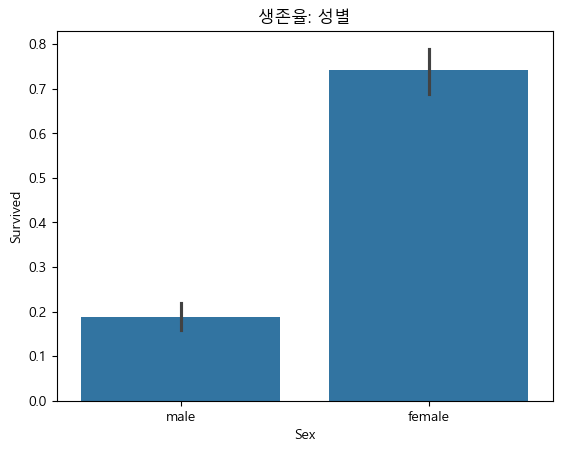

In [39]:
import matplotlib.pyplot as plt

# Set font family to Malgun Gothic (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'

# Fix for minus sign appearing as a block
plt.rcParams['axes.unicode_minus'] = False

# 탐색적 데이터 분석 (EDA): 성별별 생존율 시각화
sns.barplot(x='Sex', y='Survived', data=titanic_df)
plt.title('생존율: 성별')

Text(0.5, 1.0, '생존율: 객실 등급 × 성별')

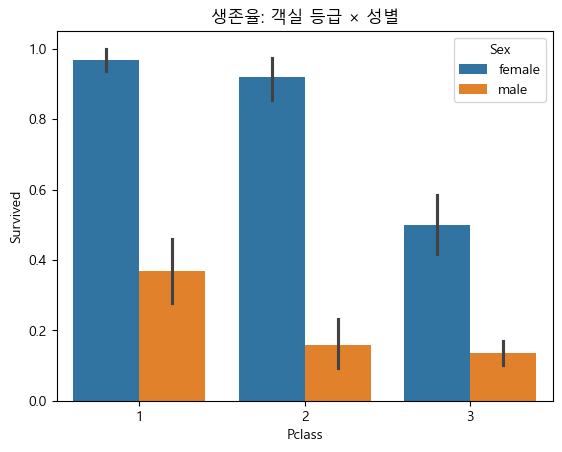

In [40]:
import matplotlib.pyplot as plt

# Set font family to Malgun Gothic (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'

# Fix for minus sign appearing as a block
plt.rcParams['axes.unicode_minus'] = False
# 객실 등급(Pclass)과 성별에 따른 생존율
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=titanic_df)
plt.title('생존율: 객실 등급 × 성별')

Text(0.5, 1.0, '생존율: 나이대 × 성별')

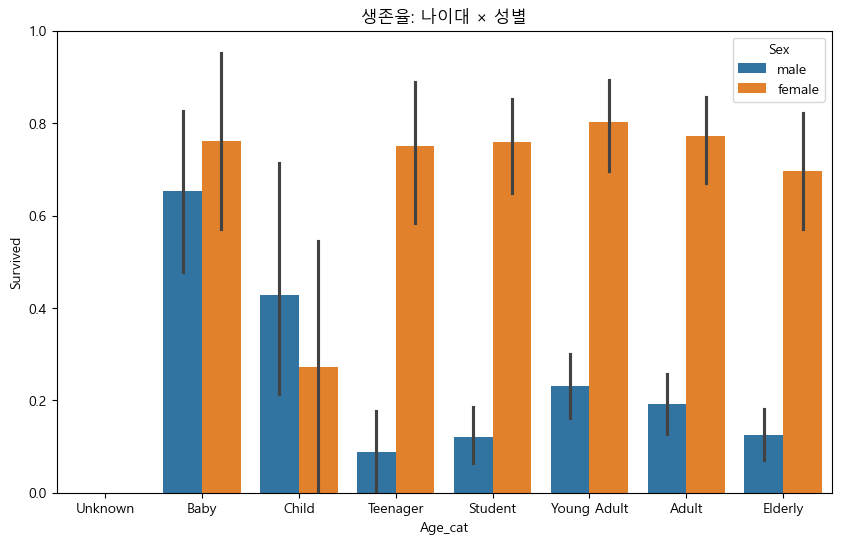

In [ ]:
# 나이대별 생존율 시각화 (apply + lambda로 범주 생성)
def get_category(age):
    if age <= -1:  return 'Unknown'
    elif age <= 5:  return 'Baby'
    elif age <= 12: return 'Child'
    elif age <= 18: return 'Teenager'
    elif age <= 25: return 'Student'
    elif age <= 35: return 'Young Adult'
    elif age <= 60: return 'Adult'
    else:           return 'Elderly'

#X축의 값을 순차적으로 표시하기 위한 설정 
# 막대그래프의 크기 figure를 더 크게 설정 
group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']
plt.figure(figsize=(10, 6))

# lambda 식에 위에서 생성한 get_category( ) 함수를 반환값으로 지정. 
# get_category(X)는 입력값으로 'Age' 컬럼값을 받아서 해당하는 cat 반환
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x: get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)
plt.title('생존율: 나이대 × 성별')

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 전처리 함수 모음 (재사용 가능하도록 함수로 묶음)
# Null c처리
def fillna(df):
    """결측값 처리"""
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df
# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
    """ID/이름/티켓번호 등 ML에 불필요한 컬럼 제거"""
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df
# 레이블 인코딩
def format_features(df):
    """문자형 범주 → 정수 레이블 인코딩"""
    df['Cabin'] = df['Cabin'].str[:1]
    for feature in ['Cabin', 'Sex', 'Embarked']:
        le = LabelEncoder()
        df[feature] = le.fit_transform(df[feature])
    return df
# 앞에서 설정한 데이터 전처리 함수 호출 
def transform_features(df):
    """위 세 함수를 순서대로 적용하는 파이프라인"""
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [34]:
# 원본 재로딩 후 전처리 적용
titanic_df = pd.read_csv(r'C:\Users\hyoli\Downloads\titanic\titanic_train.csv')
#titanic_df = pd.read_csv('./titanic_train.csv')

y_titanic_df = titanic_df['Survived']              # label
X_titanic_df = titanic_df.drop('Survived', axis=1) # features

X_titanic_df = transform_features(X_titanic_df)

C:\Users\hyoli\AppData\Local\Temp\ipykernel_100748\2000109558.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\hyoli\AppData\Local\Temp\ipykernel_100748\2000109558.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df, y_titanic_df, test_size=0.2, random_state=11)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 세 가지 모델 동시 비교
dt_clf = DecisionTreeClassifier(random_state=11)         # 단일 결정 트리
rf_clf = RandomForestClassifier(random_state=11)         # 여러 트리의 앙상블
lr_clf = LogisticRegression(solver='liblinear')          # 선형 분류 (로지스틱)

#for함수로 묶어서 학습/예측/평가 반복. 
for name, clf in [('DecisionTree', dt_clf),
                  ('RandomForest', rf_clf),
                  ('LogisticRegression', lr_clf)]:
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    print('{} 정확도: {:.4f}'.format(name, accuracy_score(y_test, pred)))

DecisionTree 정확도: 0.7877
RandomForest 정확도: 0.8547
LogisticRegression 정확도: 0.8659


In [42]:
from sklearn.model_selection import KFold

# K-Fold 교차검증 함수화
def exec_kfold(clf, folds=5):
    # 폴드 세트를 5개인 KFold객체를 생성, 폴드 수만큼 예측결과 저장을 위한  리스트 객체 생성.
    kfold  = KFold(n_splits=folds)
    scores = []
    # KFold 교차 검증 수행. 
    for iter_count , (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
        # X_titanic_df 데이터에서 교차 검증별로 학습과 검증 데이터를 가리키는 index 생성
        X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        
        # Classifier 학습, 예측, 정확도 계산 
        clf.fit(X_train, y_train) 
        predictions = clf.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        scores.append(accuracy)
        print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))     
    
    # 5개 fold에서의 평균 정확도 계산. 
    mean_score = np.mean(scores)
    print("평균 정확도: {0:.4f}".format(mean_score)) 
# exec_kfold 호출
exec_kfold(dt_clf , folds=5) 

교차 검증 0 정확도: 0.7542
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8202
평균 정확도: 0.7823


In [ ]:
from sklearn.model_selection import GridSearchCV

# 결정 트리 하이퍼파라미터 최적화
# max_depth, min_samples_split, min_samples_leaf 조합 탐색
parameters = {
    'max_depth':         [2, 3, 5, 10],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf':  [1, 5, 8]
}

grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv=5)
grid_dclf.fit(X_train, y_train)

print('최적 파라미터:', grid_dclf.best_params_)
print('최고 CV 정확도: {0:.4f}'.format(grid_dclf.best_score_))
#GridsearchCV 후에 최적 하이퍼 파라미터 학습 후 나머지 예측 및 평가
best_dclf = grid_dclf.best_estimator_
acc = accuracy_score(y_test, best_dclf.predict(X_test))
print('테스트 정확도: {0:.4f}'.format(acc))

최적 파라미터: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
최고 CV 정확도: 0.7992
테스트 정확도: 0.8715


---
## 정리

| 주제 | 핵심 내용 |
|------|----------|
| 기본 흐름 | load → split → fit → predict → score |
| 교차검증 | KFold / StratifiedKFold / cross_val_score |
| 하이퍼파라미터 | GridSearchCV로 자동 탐색 |
| 인코딩 | LabelEncoder (순서 있는 수치화), OneHotEncoder (독립 이진화) |
| 스케일링 | StandardScaler (표준화), MinMaxScaler (정규화) — test에는 transform만! |